# What drives the price of a car?

![](images/kurt.jpeg)

**OVERVIEW**

In this application, you will explore a dataset from Kaggle. The original dataset contained information on 3 million used cars. The provided dataset contains information on 426K cars to ensure speed of processing.  Your goal is to understand what factors make a car more or less expensive.  As a result of your analysis, you should provide clear recommendations to your client -- a used car dealership -- as to what consumers value in a used car.

### CRISP-DM Framework

<center>
    <img src = images/crisp.png width = 50%/>
</center>


To frame the task, throughout our practical applications, we will refer back to a standard process in industry for data projects called CRISP-DM.  This process provides a framework for working through a data problem.  Your first step in this application will be to read through a brief overview of CRISP-DM [here](https://mo-pcco.s3.us-east-1.amazonaws.com/BH-PCMLAI/module_11/readings_starter.zip).  After reading the overview, answer the questions below.

### Business Understanding

From a business perspective, we are tasked with identifying key drivers for used car prices.  In the CRISP-DM overview, we are asked to convert this business framing to a data problem definition.  Using a few sentences, reframe the task as a data task with the appropriate technical vocabulary.

*The requirements from a business perspective for this project is to understand what key factors impact the price of a car.*

*For our client, a used car dealership, we aim to understand what factors make a car more or less expensive. By applying the CRISP-DM Framework, I will better be able to guide the client on how to maximize profit based on various factors for the used cars they will sell.*

### Data Understanding

After considering the business understanding, we want to get familiar with our data.  Write down some steps that you would take to get to know the dataset and identify any quality issues within.  Take time to get to know the dataset and explore what information it contains and how this could be used to inform your business understanding.

Steps:


*   Import and take a look at the data (something like .head) for a preview
*   Identify the columns/features, values, missing data, NaN values, etc.
*   Replace any missing/null values
* Encode values as needed to reduce dimensionality if applicable
* Evaluate the various factors (via the data) that influence a car's price




In [37]:
import pandas as pd
import numpy as np
import scipy as sp

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import TargetEncoder
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.feature_selection import RFE
from sklearn.inspection import permutation_importance
from sklearn.compose import make_column_transformer, TransformedTargetRegressor, ColumnTransformer
from sklearn.model_selection import train_test_split, KFold, GridSearchCV
from sklearn.linear_model import LinearRegression, ElasticNet, Ridge, Lasso, ARDRegression, BayesianRidge
from sklearn.kernel_ridge import KernelRidge
from sklearn.datasets import make_regression
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_squared_log_error, mean_absolute_percentage_error
import io

In [31]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import make_column_transformer
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn import set_config
set_config("figure")

In [6]:
data = pd.read_csv('data/vehicles.csv')
data.head()

,id,region,price,year,manufacturer,model,condition,cylinders,fuel,odometer,title_status,transmission,VIN,drive,size,type,paint_color,state
0,7222695916,prescott,6000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,az
1,7218891961,fayetteville,11900,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ar
2,7221797935,florida keys,21000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,fl
3,7222270760,worcester / central MA,1500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ma
4,7210384030,greensboro,4900,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,nc


In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 426880 entries, 0 to 426879
Data columns (total 18 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            426880 non-null  int64  
 1   region        426880 non-null  object 
 2   price         426880 non-null  int64  
 3   year          425675 non-null  float64
 4   manufacturer  409234 non-null  object 
 5   model         421603 non-null  object 
 6   condition     252776 non-null  object 
 7   cylinders     249202 non-null  object 
 8   fuel          423867 non-null  object 
 9   odometer      422480 non-null  float64
 10  title_status  418638 non-null  object 
 11  transmission  424324 non-null  object 
 12  VIN           265838 non-null  object 
 13  drive         296313 non-null  object 
 14  size          120519 non-null  object 
 15  type          334022 non-null  object 
 16  paint_color   296677 non-null  object 
 17  state         426880 non-null  object 
dtypes: f

How many null values are there?

In [8]:
print(data.isnull().sum())

id                   0
region               0
price                0
year              1205
manufacturer     17646
model             5277
condition       174104
cylinders       177678
fuel              3013
odometer          4400
title_status      8242
transmission      2556
VIN             161042
drive           130567
size            306361
type             92858
paint_color     130203
state                0
dtype: int64


Lets visualize the missing data as well

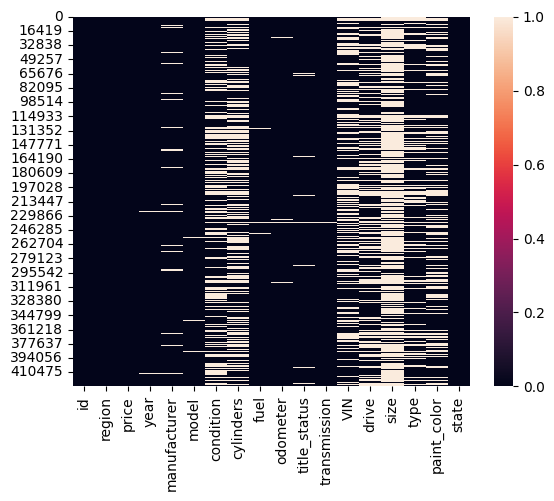

In [9]:
plot = sns.heatmap(data.isna())

In [10]:
print(data.isnull().sum()/data.shape[0]*100)

id               0.000000
region           0.000000
price            0.000000
year             0.282281
manufacturer     4.133714
model            1.236179
condition       40.785232
cylinders       41.622470
fuel             0.705819
odometer         1.030735
title_status     1.930753
transmission     0.598763
VIN             37.725356
drive           30.586347
size            71.767476
type            21.752717
paint_color     30.501078
state            0.000000
dtype: float64


Lets also investigate what the possible values are and quantities of each for each column in the dataset

In [11]:
for column in data.columns:
    print(f"Column: {column}")
    print(data[column].value_counts())
    print("-" * 40)

Column: id
id
7222695916    1
7313139418    1
7313423023    1
7313423324    1
7313424533    1
             ..
7314655506    1
7314655833    1
7314657468    1
7314659947    1
7301591129    1
Name: count, Length: 426880, dtype: int64
----------------------------------------
Column: region
region
columbus                   3608
jacksonville               3562
spokane / coeur d'alene    2988
eugene                     2985
fresno / madera            2983
                           ... 
meridian                     28
southwest MS                 14
kansas city                  11
fort smith, AR                9
west virginia (old)           8
Name: count, Length: 404, dtype: int64
----------------------------------------
Column: price
price
0        32895
6995      3169
7995      3129
9995      2867
8995      2837
         ...  
21298        1
49217        1
63195        1
19709        1
17873        1
Name: count, Length: 15655, dtype: int64
----------------------------------------
Column



# Columns
1.   id
2.   region
3.    price
4. year
    - 0.2% null values. Replace with mean value.
5. manufacturer
    - 4.1% null values with columns to be dropped. Manufacturer of a car is pretty crucial to identifying a car so if we do not have values for it, it doesn't make much sense to try to replace it with another value (most common manufacturer for example). Instead, these rows will be omitted after cleaning. 4.1% null is also a pretty small portion of our dataset so it should be ok to remove and would be unlikely to harm the level of meaning to be gathered from this dataset.
6. model
    - 1.2% null values. Although the model of a car is also critical to identifying it, it may not be necessary to remove the columns with null model value since other important information can be found from other columns (like manufacturer).
7. condition
    - 41% null values. Replace missing values with 'good' which is the most common.
8. cylinders
    - 41% null values. Replace 'other' value and missing values in this column with '6 cylinders' which is the most common.
9. fuel
    - 0.7% null values. Replace with most common value.
10. odometer
    - 1% null values.  Replace with most common value.
11. title status
    - 1.9% null values.  Replace with most common value.
12. transmission
    - 0.6% null values.  Replace with most common value.
13. VIN
    - 37.7% null values. There is a significant # of values missing here, but it isn't really useful for what we want to explore as far as understanding what factors make a car more or less expensive. Will remove this column.
14. drive
    - 30.6% null values. Given the high percentage of missing values here, the missing values will be replaced with some placeholder like 'Other' as to not distort/mistakenly create relationships between factors.
15. size
    - 71.8% null values. Given the high percentage of missing values here, the missing values will be replaced with some placeholder like 'Other' as to not distort/mistakenly create relationships between factors.
16. type
    - 21.75% null values. Given the high percentage of missing values here, the missing values will be replaced with some placeholder like 'Other' as to not distort/mistakenly create relationships between factors.
17. paint color
    - 30.5% null values. Given the high percentage of missing values here, the missing values will be replaced with some placeholder like 'Other' as to not distort/mistakenly create relationships between factors.
18. state



### Data Preparation

After our initial exploration and fine-tuning of the business understanding, it is time to construct our final dataset prior to modeling.  Here, we want to make sure to handle any integrity issues and cleaning, the engineering of new features, any transformations that we believe should happen (scaling, logarithms, normalization, etc.), and general preparation for modeling with `sklearn`.

In [12]:
data.describe()

,id,price,year,odometer
count,4.268800e+05,4.268800e+05,425675.000000,4.224800e+05
mean,7.311487e+09,7.519903e+04,2011.235191,9.804333e+04
std,4.473170e+06,1.218228e+07,9.452120,2.138815e+05
min,7.207408e+09,0.000000e+00,1900.000000,0.000000e+00
25%,7.308143e+09,5.900000e+03,2008.000000,3.770400e+04
50%,7.312621e+09,1.395000e+04,2013.000000,8.554800e+04
75%,7.315254e+09,2.648575e+04,2017.000000,1.335425e+05
max,7.317101e+09,3.736929e+09,2022.000000,1.000000e+07


### Time to replace missing/null values in our dataset

In [13]:
# VIN, id, and region can all be dropped since VIN and id are both unique
# and do not give us any additional info for our analysis.
# Region = location = State which is another column that already exists so
# removing Region as to not duplicate this feature.

cleaned_data = data.drop(['id', 'region', 'VIN'], axis=1)

# Verify the remaining columns
cleaned_data.columns.tolist()

['price',
 'year',
 'manufacturer',
 'model',
 'condition',
 'cylinders',
 'fuel',
 'odometer',
 'title_status',
 'transmission',
 'drive',
 'size',
 'type',
 'paint_color',
 'state']

In [14]:
# Sanity check - any prices not > $0 should also be dropped
cleaned_data = cleaned_data[cleaned_data['price'] > 0]

cleaned_data_sorted = cleaned_data.sort_values(by='price', ascending=True)
cleaned_data_sorted.head()

,price,year,manufacturer,model,condition,cylinders,fuel,odometer,title_status,transmission,drive,size,type,paint_color,state
331228,1,1957.0,chevrolet,corvette convertible,good,8 cylinders,gas,1.0,clean,manual,NaN,NaN,NaN,NaN,pa
146862,1,2015.0,dodge,grand caravan se,excellent,6 cylinders,gas,138078.0,clean,automatic,fwd,full-size,mini-van,red,il
102982,1,2016.0,chevrolet,tahoe,excellent,8 cylinders,gas,94282.0,clean,other,4wd,full-size,SUV,silver,fl
93167,1,2013.0,bmw,7 series,excellent,8 cylinders,gas,66035.0,clean,other,4wd,compact,sedan,silver,fl
114813,1,2015.0,chevrolet,impala,NaN,NaN,gas,100000.0,clean,automatic,NaN,NaN,NaN,NaN,fl


Seems strange that some of these cars are price of 1 but are even in excellent conidition and even less than 10 years old.

Lets try to bump up the min price threshold. Otherwise, I don't think data like a $1 2013 BMW 7 series with only 66k miles makes much sense and would likely skew our data/relationships.

Briefly Googled min price of a car for 30 years old and seems like as low as a few hundred dollars is a good starting point.

Adjusting threshold to $200

In [15]:
# Lets set $200 as the threhsold
cleaned_data = cleaned_data[cleaned_data['price'] > 200]

cleaned_data_sorted = cleaned_data.sort_values(by='price', ascending=True)
cleaned_data_sorted.head(20)

,price,year,manufacturer,model,condition,cylinders,fuel,odometer,title_status,transmission,drive,size,type,paint_color,state
192033,201,2011.0,cadillac,cts 3.6l premium awd,excellent,6 cylinders,gas,93336.0,NaN,automatic,4wd,NaN,sedan,NaN,ma
213640,201,2010.0,chevrolet,silverado 1500 lt,NaN,8 cylinders,gas,181273.0,clean,automatic,4wd,NaN,NaN,NaN,mn
60992,201,2016.0,mini,cooper hardtop 4 door 4dr,NaN,4 cylinders,gas,65035.0,clean,automatic,fwd,NaN,sedan,NaN,ca
192131,201,2012.0,mercedes-benz,glk-class glk350,excellent,6 cylinders,gas,140729.0,NaN,automatic,4wd,NaN,SUV,NaN,ma
192516,201,2011.0,cadillac,cts 3.6l premium awd,excellent,6 cylinders,gas,93336.0,NaN,automatic,4wd,NaN,sedan,NaN,ma
33815,202,2017.0,hyundai,sonata 2.4l,excellent,4 cylinders,gas,113549.0,NaN,automatic,NaN,NaN,other,NaN,ca
296455,202,2016.0,ford,explorer 4wd v6,good,6 cylinders,other,122611.0,clean,automatic,4wd,NaN,SUV,white,oh
418463,203,2018.0,ford,focus,NaN,4 cylinders,gas,35882.0,clean,automatic,fwd,NaN,sedan,black,wi
60985,203,2017.0,volkswagen,golf gti c,NaN,4 cylinders,gas,60974.0,clean,manual,fwd,NaN,hatchback,NaN,ca
312114,203,2004.0,nissan,titan,NaN,8 cylinders,gas,157742.0,clean,automatic,4wd,NaN,truck,NaN,or


In [21]:
# Fill missing year with mean of the column
cleaned_data['year'] = cleaned_data['year'].mean()

# Drop rows with no manufacturer
cleaned_data = cleaned_data.dropna(subset=['manufacturer'])

# Fill missing model values with 'Other'
cleaned_data['model'] = cleaned_data['model'].fillna('Other')

# Fill missing condition values with 'good'
cleaned_data['condition'] = cleaned_data['condition'].fillna('good')

# Fill missing cylinder values with '6 cylinders'
cleaned_data['cylinders'] = cleaned_data['cylinders'].fillna('6 cylinders')

# Fill missing fuel values with the mean
most_frequent_fuel = cleaned_data['fuel'].mode()[0]
cleaned_data['fuel'] = cleaned_data['fuel'].fillna(most_frequent_fuel)

# Fill missing odometer values with the mean
cleaned_data['odometer'] = cleaned_data['odometer'].fillna(cleaned_data['odometer'].mean())

# Fill missing title values with most common
cleaned_data['title_status'] = cleaned_data['title_status'].fillna('clean')

# Fill missing transmissison, drive, size, type, and paint color values with 'Other'
columns_to_fill = ['transmission', 'drive', 'size', 'type', 'paint_color']
cleaned_data[columns_to_fill] = cleaned_data[columns_to_fill].fillna('Other')


cleaned_data.head()

,price,year,manufacturer,model,condition,cylinders,fuel,odometer,title_status,transmission,drive,size,type,paint_color,state
27,33590,2011.01202,gmc,sierra 1500 crew cab slt,good,8 cylinders,gas,57923.0,clean,other,Other,Other,pickup,white,al
28,22590,2011.01202,chevrolet,silverado 1500,good,8 cylinders,gas,71229.0,clean,other,Other,Other,pickup,blue,al
29,39590,2011.01202,chevrolet,silverado 1500 crew,good,8 cylinders,gas,19160.0,clean,other,Other,Other,pickup,red,al
30,30990,2011.01202,toyota,tundra double cab sr,good,8 cylinders,gas,41124.0,clean,other,Other,Other,pickup,red,al
31,15000,2011.01202,ford,f-150 xlt,excellent,6 cylinders,gas,128000.0,clean,automatic,rwd,full-size,truck,black,al


In [24]:
# Checking for null values after cleaning:
print(cleaned_data.isnull().sum())

price           0
year            0
manufacturer    0
model           0
condition       0
cylinders       0
fuel            0
odometer        0
title_status    0
transmission    0
drive           0
size            0
type            0
paint_color     0
state           0
dtype: int64


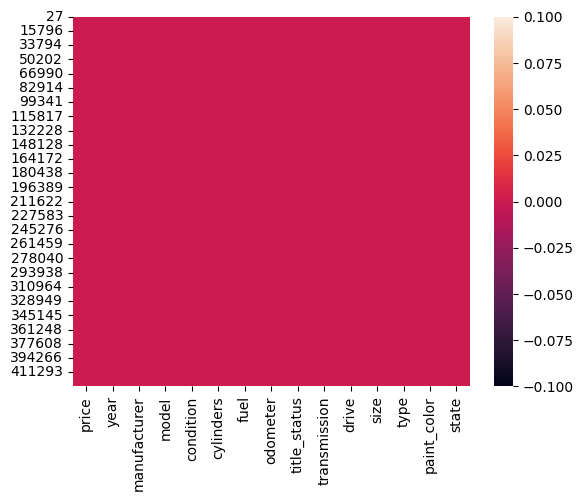

In [25]:
# Visualizing again with heat map to confirm we have filled/dropped all missing values
plot = sns.heatmap(cleaned_data.isna())

### Modeling

With your (almost?) final dataset in hand, it is now time to build some models.  Here, you should build a number of different regression models with the price as the target.  In building your models, you should explore different parameters and be sure to cross-validate your findings.

In [ ]:
# Given our data has high cardinality (manufacturer and model for example),
# will use target encooding to reduce the dimensionality
features = X.columns

target_encoder = TargetEncoder(smooth="auto")

cleaned_data_encoded = target_encoder.fit_transform(cleaned_data[features], cleaned_data["price"])

In [ ]:
# Splitting the dataset into Train Test splits
X = cleaned_data_encoded.drop('price', axis = 1)
y = cleaned_data_encoded['price']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25, random_state = 42)

In [29]:
X_train

,year,manufacturer,model,condition,cylinders,fuel,odometer,title_status,transmission,drive,size,type,paint_color,state
331838,2011.01202,acura,mdx,good,6 cylinders,gas,115150.0,clean,automatic,4wd,Other,sedan,Other,pa
160500,2011.01202,dodge,magnum rt,excellent,8 cylinders,gas,163000.0,clean,automatic,rwd,compact,sedan,black,ia
43844,2011.01202,mercedes-benz,gla,good,4 cylinders,gas,33875.0,clean,automatic,4wd,compact,SUV,grey,ca
127648,2011.01202,dodge,durango 2wd 4dr r/t,good,8 cylinders,gas,70991.0,clean,automatic,rwd,Other,SUV,Other,hi
416392,2011.01202,porsche,cayenne s awd luxury suv,good,6 cylinders,gas,159937.0,clean,automatic,Other,Other,Other,Other,wi
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
294767,2011.01202,gmc,sierra,good,6 cylinders,gas,159865.0,clean,automatic,4wd,Other,pickup,Other,oh
418824,2011.01202,infiniti,qx60 base,excellent,6 cylinders,gas,36812.0,clean,automatic,4wd,Other,SUV,Other,wi
151070,2011.01202,kia,sedona,good,6 cylinders,gas,186045.0,clean,automatic,Other,Other,Other,Other,in
167636,2011.01202,ram,Other,good,6 cylinders,diesel,240672.0,clean,automatic,4wd,Other,pickup,silver,ks


In [36]:
Linear_pipe =  Pipeline([('scaler', StandardScaler()), ('linear', LinearRegression())])

Linear_pipe.fit(X_train, y_train)
train_predict = Linear_pipe.predict(X_train)
test_predict = Linear_pipe.predict(X_test)

#Regression Error
Linear_train_mse = mean_squared_error(train_predict, y_train)
Linear_test_mse = mean_squared_error(test_predict, y_test)
Linear_train_mae = mean_absolute_error(train_predict, y_train)
Linear_test_mae = mean_absolute_error(test_predict, y_test)

linear_coefs = Linear_pipe.named_steps['linear'].coef_
print(Linear_pipe)
print(linear_coefs)

print(f"Linear Model: train_mse={Linear_train_mse}, test_mse={Linear_test_mse}")
print(f"Linear Model: train_mae={Linear_train_mae}, test_mae={Linear_test_mae}")
print(Linear_pipe.score(X_test, y_test))

ValueError: could not convert string to float: 'acura'

# Lasso
- pipeline
- fit/predict
- calculate regression error

# Ridge
- pipeline
- fit/predict
- calculate regression error

### Evaluation

With some modeling accomplished, we aim to reflect on what we identify as a high-quality model and what we are able to learn from this.  We should review our business objective and explore how well we can provide meaningful insight into drivers of used car prices.  Your goal now is to distill your findings and determine whether the earlier phases need revisitation and adjustment or if you have information of value to bring back to your client.

*Would like to be able to compare the various errors from regression types to understand how each model performs.*

### Deployment

Now that we've settled on our models and findings, it is time to deliver the information to the client.  You should organize your work as a basic report that details your primary findings.  Keep in mind that your audience is a group of used car dealers interested in fine-tuning their inventory.

*Would like to be able to come up with some guidance as far as models/manufacturers of cars that tend to perform better. Also, what years sell better and odometer value.*

*These are pretty standard recommendations though and unfortunately do not have the data from regression techniques due to extremely long target encoding process (over 1.5 hours and still has not finished).*

*Thus, after the encoding cell I just have rough outlines of what the plan was since I am not able to finish executing that cell in time.*